In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Connect to database
conn = sqlite3.connect('C:/Users/D E L L/Desktop/CODING/vendor_invoice_intelligence/data/inventory.db')
# Load the data
query = "SELECT * FROM vendor_invoice"
vendor_df = pd.read_sql_query(query, conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN


          Quantity   Dollars   Freight
Quantity  1.000000  0.963831  0.946550
Dollars   0.963831  1.000000  0.985141
Freight   0.946550  0.985141  1.000000


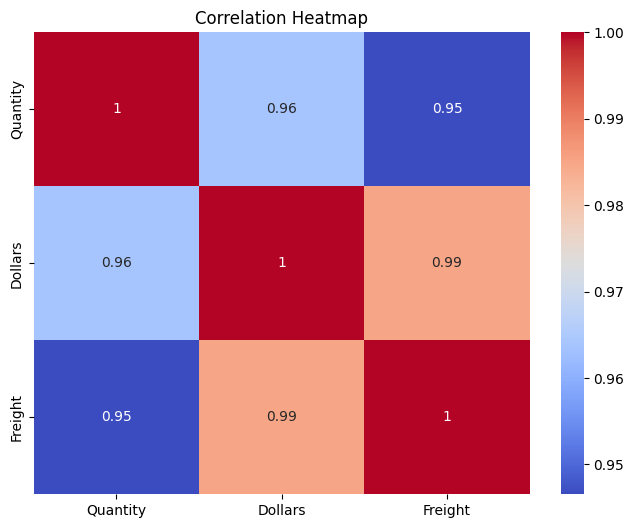

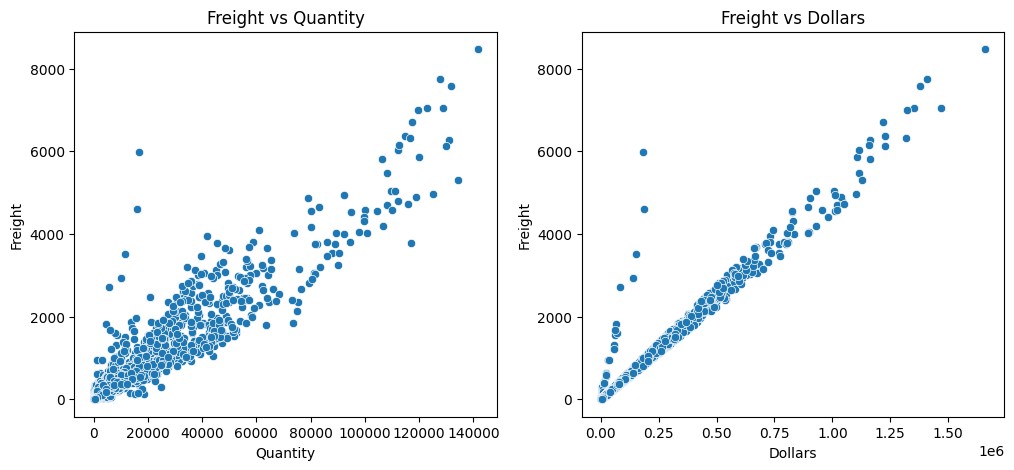

In [2]:
# Check correlation between quantity, dollars, and freight
corr_df = vendor_df[['Quantity', 'Dollars', 'Freight']]
correlation_matrix = corr_df.corr()
print(correlation_matrix)

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Plot Scatter plots to see the straight line relationship
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=vendor_df, x='Quantity', y='Freight', ax=ax[0])
ax[0].set_title('Freight vs Quantity')
sns.scatterplot(data=vendor_df, x='Dollars', y='Freight', ax=ax[1])
ax[1].set_title('Freight vs Dollars')
plt.show()

In [3]:
# Calculate freight per unit
vendor_df['freight_per_unit'] = vendor_df['Freight'] / vendor_df['Quantity']

# Find 25th percentile (Low Quantity) and 75th percentile (High Quantity)
low_qty_threshold = vendor_df['Quantity'].quantile(0.25)
high_qty_threshold = vendor_df['Quantity'].quantile(0.75)

low_qty_vendors = vendor_df[vendor_df['Quantity'] <= low_qty_threshold]
high_qty_vendors = vendor_df[vendor_df['Quantity'] >= high_qty_threshold]

print(f"Average Freight per Unit (Low Qty < {low_qty_threshold}): ${low_qty_vendors['freight_per_unit'].mean():.4f}")
print(f"Average Freight per Unit (High Qty > {high_qty_threshold}): ${high_qty_vendors['freight_per_unit'].mean():.4f}")
# Conclusion: Bulk orders have a cheaper per-unit freight cost!

Average Freight per Unit (Low Qty < 83.0): $0.0946
Average Freight per Unit (High Qty > 5100.5): $0.0491


In [4]:
# Drop NAs
vendor_df = vendor_df.dropna(subset=['Quantity', 'Dollars', 'Freight'])

X = vendor_df[['Quantity', 'Dollars']]
y = vendor_df['Freight']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=4),
    "Random Forest": RandomForestRegressor(random_state=42, max_depth=4)
}

# Train and Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    print(f"{name} R2 Score: {r2:.4f}")

Linear Regression R2 Score: 0.9700
Decision Tree R2 Score: 0.9630
Random Forest R2 Score: 0.9670
